## Análisis exploratorio - EDA

In [8]:
# Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Diccionario de datos:

diccionario = pd.read_excel("/workspaces/tumipay_analysis/data/dictionary/diccionario_datos.xlsx", header=2)
diccionario

,tabla,campo,tipo_sugerido,descripcion,uso_sugerido
0,clientes,cliente_id,VARCHAR,Identificador único del cliente.,Llave primaria / cruces.
1,clientes,fecha_registro,DATE,Fecha en la que el cliente fue registrado en l...,Antigüedad del cliente.
2,clientes,departamento,VARCHAR,Departamento de residencia o registro.,Segmentación geográfica.
3,clientes,ciudad,VARCHAR,Ciudad de residencia o registro.,Segmentación geográfica; validar normalización.
4,clientes,edad,INTEGER,Edad declarada o estimada del cliente.,Variable demográfica; validar rangos.
5,clientes,genero,VARCHAR,Género reportado.,Análisis descriptivo con cuidado de sesgos.
6,clientes,estrato,INTEGER,Estrato socioeconómico reportado.,Segmentación; validar consistencia.
7,clientes,nivel_educativo,VARCHAR,Nivel educativo declarado.,Segmentación.
8,clientes,ocupacion,VARCHAR,Actividad económica principal.,Perfilamiento de riesgo/segmentación.
9,clientes,ingreso_mensual_estimado,NUMERIC,Ingreso mensual declarado o estimado en COP.,Capacidad de pago; validar nulos y outliers.


In [4]:
# Cargar insumos

clientes = pd.read_csv("/workspaces/tumipay_analysis/data/raw/clientes.csv")
creditos = pd.read_csv("/workspaces/tumipay_analysis/data/raw/creditos.csv")
pagos = pd.read_csv("/workspaces/tumipay_analysis/data/raw/pagos.csv")
eventos = pd.read_csv("/workspaces/tumipay_analysis/data/raw/eventos_app.csv")


In [5]:
# Revisar dimensiones y primeras filas

for nombre, df in {"Clientes": clientes, "Créditos": creditos, "Pagos": pagos, "Eventos": eventos}.items():
    print(f"\n--- {nombre} ---")
    print(df.shape)
    print(df.head(3))


--- Clientes ---
(1400, 16)
  cliente_id fecha_registro     departamento  ciudad  edad genero  estrato  \
0    CL00001     2024-03-25  Valle del Cauca    Cali    41      M        1   
1    CL00002     2025-09-27           Tolima  Ibagué    35      F        3   
2    CL00003     2024-01-19      Bogotá D.C.  Bogotá    42      F        2   

     nivel_educativo      ocupacion  ingreso_mensual_estimado  \
0  Técnico/Tecnólogo    Comerciante                 1600000.0   
1  Técnico/Tecnólogo     Pensionado                 3310000.0   
2      Universitario  Independiente                 2350000.0   

  canal_adquisicion  score_externo  tiene_producto_ahorro  \
0   Campaña digital          444.0                  False   
1          Referido          580.0                  False   
2   Campaña digital          564.0                  False   

   numero_dependientes dispositivo_principal   email_hash  
0                    2               Android  hash_732413  
1                    3          

In [ ]:
# Resumen descripción datos

def resumen_df(df, nombre):
    print(f"\nResumen de {nombre}")
    print(df.info())
    print("\nValores nulos:")
    print(df.isnull().sum())
    print("\nDescripción estadística:")
    print(df.describe(include="all"))

# Aplicar a cada dataset
resumen_df(clientes, "Clientes")
resumen_df(creditos, "Créditos")
resumen_df(pagos, "Pagos")
resumen_df(eventos, "Eventos")


Resumen de Clientes
<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                1400 non-null   str    
 1   fecha_registro            1400 non-null   str    
 2   departamento              1400 non-null   str    
 3   ciudad                    1400 non-null   str    
 4   edad                      1400 non-null   int64  
 5   genero                    1400 non-null   str    
 6   estrato                   1400 non-null   int64  
 7   nivel_educativo           1400 non-null   str    
 8   ocupacion                 1400 non-null   str    
 9   ingreso_mensual_estimado  1330 non-null   float64
 10  canal_adquisicion         1400 non-null   str    
 11  score_externo             1351 non-null   float64
 12  tiene_producto_ahorro     1400 non-null   bool   
 13  numero_dependientes       1400 non-null   int64  
 14

In [9]:
# Análisis medidas de tendencia central:

def estadisticas_numericas(df, nombre):
    print(f"\nEstadísticas numéricas de {nombre}")
    print(df.select_dtypes(include=np.number).agg(["mean", "median", "std", "min", "max"]))

estadisticas_numericas(clientes, "Clientes")
estadisticas_numericas(creditos, "Créditos")
estadisticas_numericas(pagos, "Pagos")



Estadísticas numéricas de Clientes
             edad   estrato  ingreso_mensual_estimado  score_externo  \
mean    36.500714  2.804286              2.897158e+06     592.398224   
median  36.000000  3.000000              2.570000e+06     588.000000   
std      9.838002  1.201730              3.500335e+06      85.834802   
min     17.000000  1.000000             -1.000000e+00     359.000000   
max     82.000000  6.000000              1.200000e+08     850.000000   

        numero_dependientes  
mean               1.254286  
median             1.000000  
std                1.180456  
min                0.000000  
max                4.000000  

Estadísticas numéricas de Créditos
        monto_credito  plazo_meses  tasa_interes_mensual  valor_cuota_pactada  \
mean     2.548854e+06     9.569745              0.029231         4.004237e+05   
median   1.850000e+06     9.000000              0.028700         2.610000e+05   
std      2.352297e+06     5.222715              0.007902         4.54862

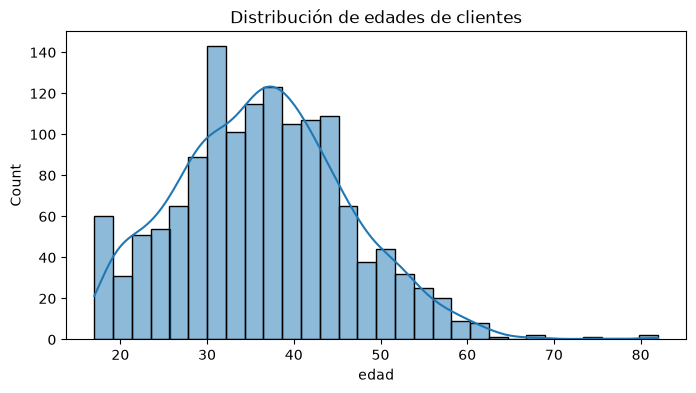

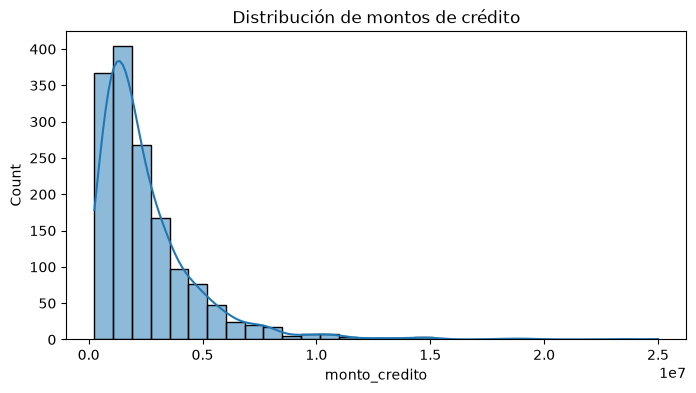

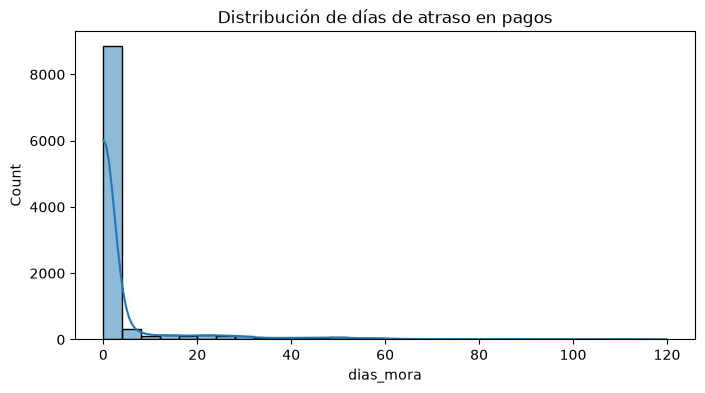

In [11]:
# Distribución de edades de clientes
plt.figure(figsize=(8,4))
sns.histplot(clientes["edad"], bins=30, kde=True)
plt.title("Distribución de edades de clientes")
plt.show()

# Histograma de montos de crédito
plt.figure(figsize=(8,4))
sns.histplot(creditos["monto_credito"], bins=30, kde=True)
plt.title("Distribución de montos de crédito")
plt.show()

# Atrasos en pagos
plt.figure(figsize=(8,4))
sns.histplot(pagos["dias_mora"], bins=30, kde=True)
plt.title("Distribución de días de atraso en pagos")
plt.show()


#Conclusiones:
- En la tabla 'clientes.csv' se identifican valores negativos, nulos y atípicos. Se requiere tratemiendo para evitar fallos en el análisis y modelado.